---
## 📦 Cellule 1 — Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

os.makedirs('../models', exist_ok=True)
os.makedirs('../data', exist_ok=True)

print('✅ Tous les imports OK !')
print(f'   Scikit-Learn, XGBoost, MLflow, Joblib — prêts')

✅ Tous les imports OK !
   Scikit-Learn, XGBoost, MLflow, Joblib — prêts


---
## 📂 Cellule 2 — Chargement du dataset

In [50]:
# Charger le dataset sélectionné de la Semaine 1
# Si support2_selected.csv n'existe pas, on charge support2.csv
if os.path.exists('../data/support2_selected.csv'):
    df = pd.read_csv('../data/support2_selected.csv')
    print('✅ Chargé : data/support2_selected.csv')
else:
    df = pd.read_csv('../data/support2.csv')
    print('✅ Chargé : data/support2.csv')

print('=' * 55)
print(f'  📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'  ❓ Valeurs manquantes : {df.isnull().sum().sum()}')
print('=' * 55)
df.head()

✅ Chargé : data/support2_selected.csv
  📐 Dimensions : 9105 lignes × 24 colonnes
  ❓ Valeurs manquantes : 2858


,aps,dzgroup,meanbp,scoma,resp,d.time,wblc,death,sod,race,...,age,crea,pafi,dnr,charges,surv2m,temp,surv6m,hospdead,hrt
0,20.0,Lung Cancer,97.0,0.0,22.0,2029,6.000000,0,141.0,other,...,62.84998,1.199951,388.00000,no dnr,9715.0,0.262939,36.00000,0.036995,0,69.0
1,74.0,Cirrhosis,43.0,44.0,34.0,4,17.097656,1,132.0,white,...,60.33899,5.500000,98.00000,NaN,34496.0,0.001000,34.59375,0.000000,1,112.0
2,45.0,Cirrhosis,70.0,0.0,28.0,47,8.500000,1,134.0,white,...,52.74698,2.000000,231.65625,no dnr,41094.0,0.790894,37.39844,0.664917,0,88.0
3,19.0,Lung Cancer,75.0,0.0,32.0,133,9.099609,1,139.0,white,...,42.38498,0.799927,NaN,no dnr,3075.0,0.698975,35.00000,0.411987,0,88.0
4,30.0,ARF/MOSF w/Sepsis,59.0,26.0,20.0,2029,13.500000,0,143.0,white,...,79.88495,0.799927,173.31250,no dnr,50127.0,0.634888,37.89844,0.532959,0,112.0


---
##  Cellule 3 — Définition de la variable cible et features

In [51]:
# ── Variable cible ───────────────────────────────────────────────────
TARGET = 'death'

# ── Features pour le module IA Prédiction traitement ────────────────
FEATURES_CANDIDATES = [
    # Démographiques
    'age', 'sex', 'race',
    # Cliniques
    'dzgroup', 'num.co', 'scoma', 'dnr',
    # Physiologiques
    'hrt', 'resp', 'temp', 'meanbp', 'wblc', 'pafi', 'crea', 'sod',
    # Scores
    'aps', 'sps', 'surv2m', 'surv6m'
]

# Garder seulement les colonnes disponibles
FEATURES = [f for f in FEATURES_CANDIDATES if f in df.columns]

print('🎯 CONFIGURATION DU MODÈLE')
print('=' * 55)
print(f'  Variable cible : {TARGET}')
print(f'  Features disponibles ({len(FEATURES)}) : {FEATURES}')

# Vérifier que TARGET existe
if TARGET not in df.columns:
    print(f'\n❌ Colonne "{TARGET}" non trouvée !')
    print(f'   Colonnes disponibles : {list(df.columns)}')
else:
    print(f'\n  Distribution cible :')
    counts = df[TARGET].value_counts()
    for v, c in counts.items():
        print(f'    {v} : {c} patients ({c/len(df)*100:.1f}%)')

🎯 CONFIGURATION DU MODÈLE
  Variable cible : death
  Features disponibles (19) : ['age', 'sex', 'race', 'dzgroup', 'num.co', 'scoma', 'dnr', 'hrt', 'resp', 'temp', 'meanbp', 'wblc', 'pafi', 'crea', 'sod', 'aps', 'sps', 'surv2m', 'surv6m']

  Distribution cible :
    1 : 6201 patients (68.1%)
    0 : 2904 patients (31.9%)


---
## 🧹 Cellule 4 — Nettoyage : Suppression doublons

In [52]:
print('🧹 NETTOYAGE DES DONNÉES')
print('=' * 55)

df_original_shape = df.shape

# ── Suppression des doublons ─────────────────────────────────────────
n_doublons = df.duplicated().sum()
df = df.drop_duplicates()
print(f'  🗑️  Doublons supprimés : {n_doublons}')

# ── Supprimer lignes sans target ─────────────────────────────────────
n_avant = len(df)
df = df.dropna(subset=[TARGET])
n_apres = len(df)
print(f'  🗑️  Lignes sans target supprimées : {n_avant - n_apres}')

print(f'\n  📐 Avant nettoyage : {df_original_shape}')
print(f'  📐 Après nettoyage : {df.shape}')
print(f'  ✅ Dataset propre !')

🧹 NETTOYAGE DES DONNÉES
  🗑️  Doublons supprimés : 0
  🗑️  Lignes sans target supprimées : 0

  📐 Avant nettoyage : (9105, 24)
  📐 Après nettoyage : (9105, 24)
  ✅ Dataset propre !


---
## 🔧 Cellule 5 — Séparation numériques / catégorielles

In [53]:
# Séparer features numériques et catégorielles
df_features = df[FEATURES].copy()

NUMERIQUES   = df_features.select_dtypes(include=[np.number]).columns.tolist()
CATEGORIQUES = df_features.select_dtypes(include=['object']).columns.tolist()

print('🔧 SÉPARATION FEATURES')
print('=' * 55)
print(f'\n  🔢 Numériques ({len(NUMERIQUES)}) :')
for c in NUMERIQUES:
    missing = df_features[c].isnull().sum()
    print(f'     {c:15s} | manquants: {missing} ({missing/len(df)*100:.1f}%)')

print(f'\n  🔤 Catégorielles ({len(CATEGORIQUES)}) :')
for c in CATEGORIQUES:
    missing = df_features[c].isnull().sum()
    uniques = df_features[c].nunique()
    print(f'     {c:15s} | manquants: {missing} | valeurs uniques: {uniques}')

🔧 SÉPARATION FEATURES

  🔢 Numériques (15) :
     age             | manquants: 0 (0.0%)
     num.co          | manquants: 0 (0.0%)
     scoma           | manquants: 1 (0.0%)
     hrt             | manquants: 1 (0.0%)
     resp            | manquants: 1 (0.0%)
     temp            | manquants: 1 (0.0%)
     meanbp          | manquants: 1 (0.0%)
     wblc            | manquants: 212 (2.3%)
     pafi            | manquants: 2325 (25.5%)
     crea            | manquants: 67 (0.7%)
     sod             | manquants: 1 (0.0%)
     aps             | manquants: 1 (0.0%)
     sps             | manquants: 1 (0.0%)
     surv2m          | manquants: 1 (0.0%)
     surv6m          | manquants: 1 (0.0%)

  🔤 Catégorielles (4) :
     sex             | manquants: 0 | valeurs uniques: 2
     race            | manquants: 42 | valeurs uniques: 5
     dzgroup         | manquants: 0 | valeurs uniques: 8
     dnr             | manquants: 30 | valeurs uniques: 3


---
## 💉 Cellule 6 — Imputation des valeurs manquantes

In [54]:
print('💉 IMPUTATION DES VALEURS MANQUANTES')
print('=' * 55)

df_clean = df[FEATURES + [TARGET]].copy()

# ── Imputation numériques → médiane ──────────────────────────────────
if NUMERIQUES:
    imputer_num = SimpleImputer(strategy='median')
    df_clean[NUMERIQUES] = imputer_num.fit_transform(df_clean[NUMERIQUES])
    print(f'  ✅ Numériques imputées avec la MÉDIANE ({len(NUMERIQUES)} colonnes)')

# ── Imputation catégorielles → mode ──────────────────────────────────
if CATEGORIQUES:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df_clean[CATEGORIQUES] = imputer_cat.fit_transform(df_clean[CATEGORIQUES])
    print(f'  ✅ Catégorielles imputées avec le MODE ({len(CATEGORIQUES)} colonnes)')

# Vérification
remaining_missing = df_clean.isnull().sum().sum()
print(f'\n  ❓ Valeurs manquantes restantes : {remaining_missing}')
if remaining_missing == 0:
    print('  🎉 Aucune valeur manquante !')
else:
    print('  ⚠️  Vérifier les colonnes restantes !')

💉 IMPUTATION DES VALEURS MANQUANTES
  ✅ Numériques imputées avec la MÉDIANE (15 colonnes)
  ✅ Catégorielles imputées avec le MODE (4 colonnes)

  ❓ Valeurs manquantes restantes : 0
  🎉 Aucune valeur manquante !


---
## 🔠 Cellule 7 — Encodage des variables catégorielles

In [55]:
print('🔠 ENCODAGE DES VARIABLES CATÉGORIELLES')
print('=' * 55)

label_encoders = {}

if CATEGORIQUES:
    for col in CATEGORIQUES:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le
        print(f'  ✅ {col:15s} → {len(le.classes_)} classes encodées : {list(le.classes_[:5])}...')
    
    # Sauvegarder les encodeurs
    joblib.dump(label_encoders, '../models/label_encoders.pkl')
    print(f'\n  💾 Encodeurs sauvegardés : models/label_encoders.pkl')
else:
    print('  ℹ️  Aucune colonne catégorielle à encoder')

print(f'\n  📐 Dataset après encodage : {df_clean.shape}')
df_clean.head(3)

🔠 ENCODAGE DES VARIABLES CATÉGORIELLES
  ✅ sex             → 2 classes encodées : ['female', 'male']...
  ✅ race            → 5 classes encodées : ['asian', 'black', 'hispanic', 'other', 'white']...
  ✅ dzgroup         → 8 classes encodées : ['ARF/MOSF w/Sepsis', 'CHF', 'COPD', 'Cirrhosis', 'Colon Cancer']...
  ✅ dnr             → 3 classes encodées : ['dnr after sadm', 'dnr before sadm', 'no dnr']...

  💾 Encodeurs sauvegardés : models/label_encoders.pkl

  📐 Dataset après encodage : (9105, 20)


,age,sex,race,dzgroup,num.co,scoma,dnr,hrt,resp,temp,meanbp,wblc,pafi,crea,sod,aps,sps,surv2m,surv6m,death
0,62.84998,1,3,6,0.0,0.0,2,69.0,22.0,36.00000,97.0,6.000000,388.00000,1.199951,141.0,20.0,33.898438,0.262939,0.036995,0
1,60.33899,0,4,3,2.0,44.0,2,112.0,34.0,34.59375,43.0,17.097656,98.00000,5.500000,132.0,74.0,52.695312,0.001000,0.000000,1
2,52.74698,0,4,3,2.0,0.0,2,88.0,28.0,37.39844,70.0,8.500000,231.65625,2.000000,134.0,45.0,20.500000,0.790894,0.664917,1


---
## ✂️ Cellule 8 — Split Train / Test

In [56]:
print('✂️  SPLIT TRAIN / TEST')
print('=' * 55)

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

# Split 80/20 avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # Garder la proportion survie/décès
)

print(f'  📊 Dataset complet : {X.shape[0]} patients')
print(f'  🚂 Train (80%)     : {X_train.shape[0]} patients')
print(f'  🧪 Test  (20%)     : {X_test.shape[0]} patients')
print(f'\n  Distribution dans Train :')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Survie' if u == 0 else 'Décès'
    print(f'    {u} ({label}) : {c} ({c/len(y_train)*100:.1f}%)')
print(f'\n  Distribution dans Test :')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Survie' if u == 0 else 'Décès'
    print(f'    {u} ({label}) : {c} ({c/len(y_test)*100:.1f}%)')

✂️  SPLIT TRAIN / TEST
  📊 Dataset complet : 9105 patients
  🚂 Train (80%)     : 7284 patients
  🧪 Test  (20%)     : 1821 patients

  Distribution dans Train :
    0 (Survie) : 2323 (31.9%)
    1 (Décès) : 4961 (68.1%)

  Distribution dans Test :
    0 (Survie) : 581 (31.9%)
    1 (Décès) : 1240 (68.1%)


---
## ⚖️ Cellule 9 — Normalisation StandardScaler

In [57]:
print('⚖️  NORMALISATION — StandardScaler')
print('=' * 55)

scaler = StandardScaler()

# Fit sur Train seulement → Transform sur Train et Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Sauvegarder le scaler
joblib.dump(scaler, '../models/scaler.pkl')

print(f'  ✅ StandardScaler appliqué')
print(f'  ✅ Fit sur Train uniquement (évite le data leakage)')
print(f'  💾 Scaler sauvegardé : models/scaler.pkl')
print(f'\n  Avant normalisation (X_train[0][:5]) : {X_train[0][:5].round(2)}')
print(f'  Après normalisation (X_train[0][:5]) : {X_train_scaled[0][:5].round(2)}')

⚖️  NORMALISATION — StandardScaler
  ✅ StandardScaler appliqué
  ✅ Fit sur Train uniquement (évite le data leakage)
  💾 Scaler sauvegardé : models/scaler.pkl

  Avant normalisation (X_train[0][:5]) : [75.09  1.    4.    3.    2.  ]
  Après normalisation (X_train[0][:5]) : [0.79 0.89 0.49 0.31 0.1 ]


---
## 🤖 Cellule 10 — Entraînement des 3 modèles

In [58]:
print('🤖 ENTRAÎNEMENT DES 3 MODÈLES ML')
print('=' * 55)

# ── Définition des modèles ───────────────────────────────────────────
modeles = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

resultats = {}

for nom, modele in modeles.items():
    print(f'\n  ⏳ Entraînement : {nom}...')

    # Entraînement
    modele.fit(X_train_scaled, y_train)

    # Prédictions
    y_pred      = modele.predict(X_test_scaled)
    y_pred_proba= modele.predict_proba(X_test_scaled)[:, 1]

    # Métriques
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    auc  = roc_auc_score(y_test, y_pred_proba)
    cv   = cross_val_score(modele, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()

    resultats[nom] = {
        'modele'    : modele,
        'y_pred'    : y_pred,
        'y_proba'   : y_pred_proba,
        'accuracy'  : round(acc, 4),
        'f1_score'  : round(f1, 4),
        'roc_auc'   : round(auc, 4),
        'cv_auc'    : round(cv, 4)
    }

    print(f'  ✅ {nom} terminé')
    print(f'     Accuracy : {acc:.4f} | F1 : {f1:.4f} | AUC : {auc:.4f} | CV-AUC : {cv:.4f}')

print('\n🎉 Les 3 modèles entraînés !')

🤖 ENTRAÎNEMENT DES 3 MODÈLES ML

  ⏳ Entraînement : Logistic Regression...
  ✅ Logistic Regression terminé
     Accuracy : 0.7375 | F1 : 0.7462 | AUC : 0.8294 | CV-AUC : 0.8124

  ⏳ Entraînement : Random Forest...
  ✅ Random Forest terminé
     Accuracy : 0.7545 | F1 : 0.7615 | AUC : 0.8304 | CV-AUC : 0.8192

  ⏳ Entraînement : XGBoost...
  ✅ XGBoost terminé
     Accuracy : 0.7633 | F1 : 0.7556 | AUC : 0.8216 | CV-AUC : 0.8150

🎉 Les 3 modèles entraînés !


---
## 📊 Cellule 11 — Tableau comparatif des modèles

📊 TABLEAU COMPARATIF DES MODÈLES
             Modèle  Accuracy  F1-Score  ROC-AUC  CV-AUC
      Random Forest    0.7545    0.7615   0.8304  0.8192
Logistic Regression    0.7375    0.7462   0.8294  0.8124
            XGBoost    0.7633    0.7556   0.8216  0.8150


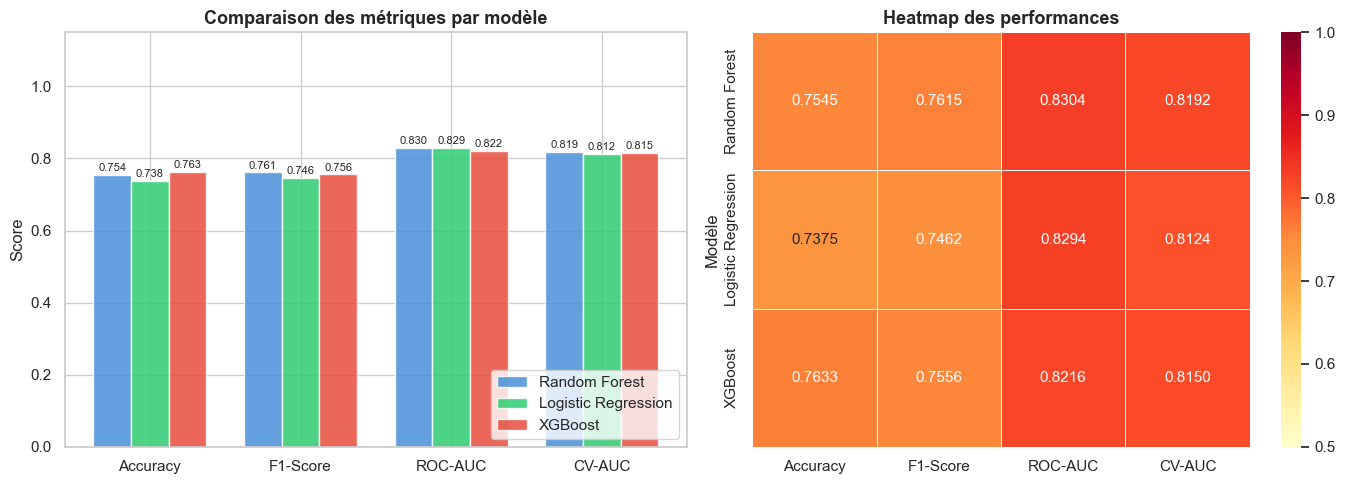

💾 Graphique sauvegardé : data/comparaison_modeles.png


,Modèle,Accuracy,F1-Score,ROC-AUC,CV-AUC
0,Random Forest,0.7545,0.7615,0.8304,0.8192
1,Logistic Regression,0.7375,0.7462,0.8294,0.8124
2,XGBoost,0.7633,0.7556,0.8216,0.8150


In [59]:
print('📊 TABLEAU COMPARATIF DES MODÈLES')
print('=' * 65)

# Créer DataFrame de comparaison
comparaison = pd.DataFrame({
    'Modèle'   : list(resultats.keys()),
    'Accuracy' : [r['accuracy'] for r in resultats.values()],
    'F1-Score' : [r['f1_score'] for r in resultats.values()],
    'ROC-AUC'  : [r['roc_auc'] for r in resultats.values()],
    'CV-AUC'   : [r['cv_auc'] for r in resultats.values()],
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(comparaison.to_string(index=False))

# ── Visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics   = ['Accuracy', 'F1-Score', 'ROC-AUC', 'CV-AUC']
modeles_n = comparaison['Modèle'].tolist()
colors    = ['#4A90D9', '#2ECC71', '#E74C3C']

# Bar chart comparatif
x     = np.arange(len(metrics))
width = 0.25
for i, (nom, color) in enumerate(zip(modeles_n, colors)):
    vals = comparaison[comparaison['Modèle'] == nom][metrics].values[0]
    bars = axes[0].bar(x + i*width, vals, width, label=nom,
                       color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Comparaison des métriques par modèle', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_ylabel('Score')

# Radar-style heatmap
heatmap_data = comparaison.set_index('Modèle')[metrics]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1], vmin=0.5, vmax=1.0,
            linewidths=0.5, annot_kws={'size': 11})
axes[1].set_title('Heatmap des performances', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Graphique sauvegardé : data/comparaison_modeles.png')

comparaison

---
## 📉 Cellule 12 — Courbes ROC

📉 COURBES ROC — Comparaison des modèles


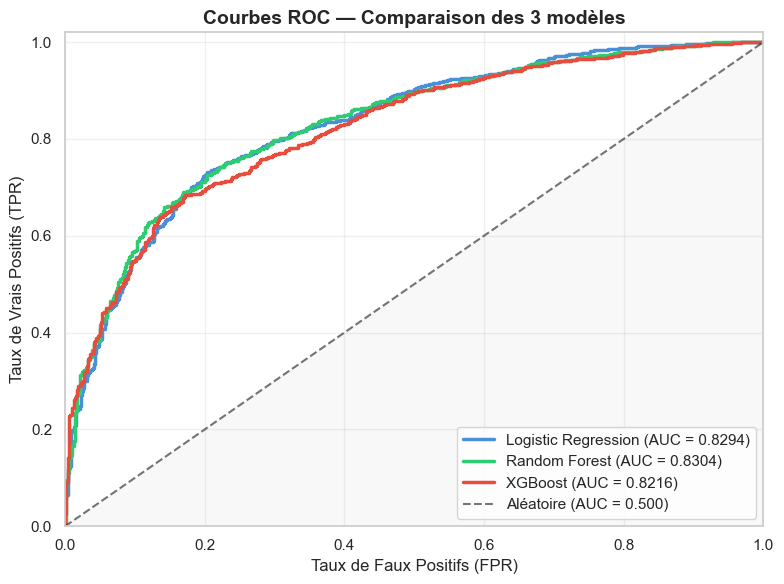

💾 Graphique sauvegardé : data/courbes_roc.png


In [60]:
print('📉 COURBES ROC — Comparaison des modèles')
print('=' * 55)

plt.figure(figsize=(8, 6))
colors = ['#4A90D9', '#2ECC71', '#E74C3C']

for (nom, res), color in zip(resultats.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = res['roc_auc']
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{nom} (AUC = {auc:.4f})')

# Ligne aléatoire
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Aléatoire (AUC = 0.500)', alpha=0.6)

plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC — Comparaison des 3 modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Graphique sauvegardé : data/courbes_roc.png')

---
## 🔲 Cellule 13 — Matrices de confusion

🔲 MATRICES DE CONFUSION

  Logistic Regression :
    TP=867 | TN=476 | FP=105 | FN=373
    Sensibilité (Recall) : 0.6992
    Spécificité          : 0.8193

  Random Forest :
    TP=925 | TN=449 | FP=132 | FN=315
    Sensibilité (Recall) : 0.7460
    Spécificité          : 0.7728

  XGBoost :
    TP=1082 | TN=308 | FP=273 | FN=158
    Sensibilité (Recall) : 0.8726
    Spécificité          : 0.5301


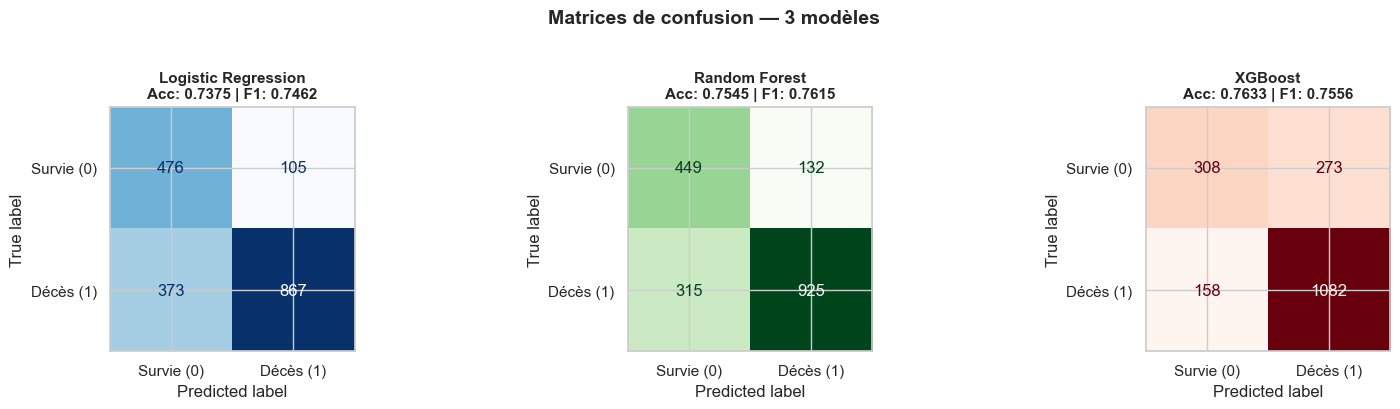


💾 Graphique sauvegardé : data/matrices_confusion.png


In [61]:
print('🔲 MATRICES DE CONFUSION')
print('=' * 55)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_cm = ['Blues', 'Greens', 'Reds']

for (nom, res), ax, cmap in zip(resultats.items(), axes, colors_cm):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Survie (0)', 'Décès (1)'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{nom}\nAcc: {res["accuracy"]:.4f} | F1: {res["f1_score"]:.4f}',
                 fontsize=11, fontweight='bold')

    # Afficher les métriques sous la matrice
    tn, fp, fn, tp = cm.ravel()
    print(f'\n  {nom} :')
    print(f'    TP={tp} | TN={tn} | FP={fp} | FN={fn}')
    sensibilite = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificite = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f'    Sensibilité (Recall) : {sensibilite:.4f}')
    print(f'    Spécificité          : {specificite:.4f}')

plt.suptitle('Matrices de confusion — 3 modèles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾 Graphique sauvegardé : data/matrices_confusion.png')

---
## 📋 Cellule 14 — Rapport de classification détaillé

In [62]:
print('📋 RAPPORTS DE CLASSIFICATION DÉTAILLÉS')
print('=' * 65)

for nom, res in resultats.items():
    print(f'\n── {nom} ──')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Survie (0)', 'Décès (1)']
    ))

📋 RAPPORTS DE CLASSIFICATION DÉTAILLÉS

── Logistic Regression ──
              precision    recall  f1-score   support

  Survie (0)       0.56      0.82      0.67       581
   Décès (1)       0.89      0.70      0.78      1240

    accuracy                           0.74      1821
   macro avg       0.73      0.76      0.72      1821
weighted avg       0.79      0.74      0.75      1821


── Random Forest ──
              precision    recall  f1-score   support

  Survie (0)       0.59      0.77      0.67       581
   Décès (1)       0.88      0.75      0.81      1240

    accuracy                           0.75      1821
   macro avg       0.73      0.76      0.74      1821
weighted avg       0.78      0.75      0.76      1821


── XGBoost ──
              precision    recall  f1-score   support

  Survie (0)       0.66      0.53      0.59       581
   Décès (1)       0.80      0.87      0.83      1240

    accuracy                           0.76      1821
   macro avg       0.73   

---
## 🏆 Cellule 15 — Sélection du meilleur modèle

In [63]:
print('🏆 SÉLECTION DU MEILLEUR MODÈLE')
print('=' * 55)

# Critère de sélection : ROC-AUC (le plus important médicalement)
meilleur_nom = max(resultats, key=lambda k: resultats[k]['roc_auc'])
meilleur_res = resultats[meilleur_nom]
meilleur_modele = meilleur_res['modele']

print(f'\n  🥇 Meilleur modèle : {meilleur_nom}')
print(f'     Accuracy : {meilleur_res["accuracy"]}')
print(f'     F1-Score : {meilleur_res["f1_score"]}')
print(f'     ROC-AUC  : {meilleur_res["roc_auc"]}')
print(f'     CV-AUC   : {meilleur_res["cv_auc"]}')

# ── Sauvegarde du meilleur modèle ────────────────────────────────────
joblib.dump(meilleur_modele, '../models/meilleur_modele.pkl')

# Sauvegarder aussi les infos du modèle
infos_modele = {
    'nom'       : meilleur_nom,
    'accuracy'  : meilleur_res['accuracy'],
    'f1_score'  : meilleur_res['f1_score'],
    'roc_auc'   : meilleur_res['roc_auc'],
    'features'  : FEATURES,
    'target'    : TARGET
}
joblib.dump(infos_modele, '../models/infos_modele.pkl')

print(f'\n  💾 Sauvegardé : models/meilleur_modele.pkl')
print(f'  💾 Sauvegardé : models/infos_modele.pkl')
print(f'  💾 Sauvegardé : models/scaler.pkl')
print(f'  💾 Sauvegardé : models/label_encoders.pkl')

🏆 SÉLECTION DU MEILLEUR MODÈLE

  🥇 Meilleur modèle : Random Forest
     Accuracy : 0.7545
     F1-Score : 0.7615
     ROC-AUC  : 0.8304
     CV-AUC   : 0.8192

  💾 Sauvegardé : models/meilleur_modele.pkl
  💾 Sauvegardé : models/infos_modele.pkl
  💾 Sauvegardé : models/scaler.pkl
  💾 Sauvegardé : models/label_encoders.pkl


---
## 🌳 Cellule 16 — Feature Importance (Random Forest / XGBoost)

🌳 FEATURE IMPORTANCE
  Top 5 features Random Forest :
    1. dnr             : 0.2295
    2. surv6m          : 0.1309
    3. dzgroup         : 0.1037
    4. surv2m          : 0.0809
    5. sps             : 0.0572
  Top 5 features XGBoost :
    1. dnr             : 0.5233
    2. dzgroup         : 0.1227
    3. surv6m          : 0.0402
    4. num.co          : 0.0337
    5. age             : 0.0273


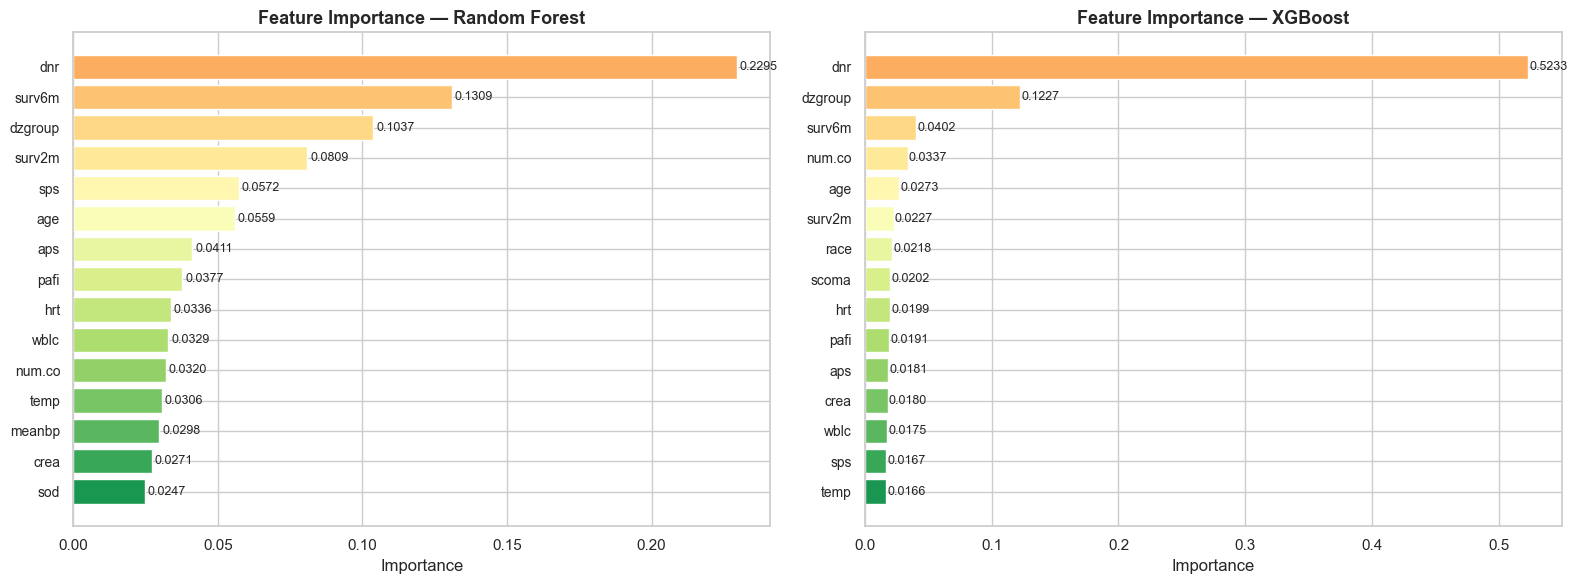


💾 Graphique sauvegardé : data/feature_importance.png


In [64]:
print('🌳 FEATURE IMPORTANCE')
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, nom in zip(axes, ['Random Forest', 'XGBoost']):
    if nom in resultats:
        modele = resultats[nom]['modele']
        importances = modele.feature_importances_

        # Trier par importance
        indices = np.argsort(importances)[::-1]
        top_n   = min(15, len(FEATURES))
        top_idx = indices[:top_n]

        feat_names = [FEATURES[i] for i in top_idx]
        feat_vals  = importances[top_idx]

        colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))[::-1]
        bars = ax.barh(range(top_n), feat_vals[::-1],
                       color=colors_fi, edgecolor='white')
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(feat_names[::-1], fontsize=10)
        ax.set_title(f'Feature Importance — {nom}',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Importance')

        for bar, val in zip(bars, feat_vals[::-1]):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=9)

        print(f'  Top 5 features {nom} :')
        for i in range(min(5, top_n)):
            print(f'    {i+1}. {FEATURES[indices[i]]:15s} : {importances[indices[i]]:.4f}')

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾 Graphique sauvegardé : data/feature_importance.png')

---
## 🧪 Cellule 17 — Test du modèle sauvegardé

In [65]:
print('🧪 TEST DU MODÈLE SAUVEGARDÉ')
print('=' * 55)

# Charger le modèle depuis le disque
modele_charge = joblib.load('../models/meilleur_modele.pkl')
scaler_charge = joblib.load('../models/scaler.pkl')
infos_charge  = joblib.load('../models/infos_modele.pkl')

print(f'  ✅ Modèle chargé : {infos_charge["nom"]}')
print(f'  ✅ Scaler chargé')

# Test sur les 5 premiers patients du test set
print(f'\n  🔮 Test sur 5 patients :')
print(f'  {"Patient":8s} | {"Réel":12s} | {"Prédit":12s} | {"Proba Décès":12s} | {"Correct"}')
print(f'  {"-"*65}')

X_sample = X_test_scaled[:5]
y_sample = y_test[:5]
y_pred_s = modele_charge.predict(X_sample)
y_prob_s = modele_charge.predict_proba(X_sample)[:, 1]

labels = {0: 'Survie', 1: 'Décès'}
for i in range(5):
    correct = '✅' if y_pred_s[i] == y_sample[i] else '❌'
    print(f'  Patient {i+1:2d} | {labels[y_sample[i]]:12s} | {labels[y_pred_s[i]]:12s} | {y_prob_s[i]:.4f}       | {correct}')

print(f'\n  ✅ Le modèle chargé fonctionne correctement !')

🧪 TEST DU MODÈLE SAUVEGARDÉ
  ✅ Modèle chargé : Random Forest
  ✅ Scaler chargé

  🔮 Test sur 5 patients :
  Patient  | Réel         | Prédit       | Proba Décès  | Correct
  -----------------------------------------------------------------
  Patient  1 | Décès        | Décès        | 0.8874       | ✅
  Patient  2 | Décès        | Survie       | 0.4101       | ❌
  Patient  3 | Survie       | Décès        | 0.5279       | ❌
  Patient  4 | Survie       | Décès        | 0.5049       | ❌
  Patient  5 | Survie       | Survie       | 0.2632       | ✅

  ✅ Le modèle chargé fonctionne correctement !


---
## 📊 Cellule 18 — Tracking MLflow

In [66]:
print('📊 TRACKING MLFLOW — Semaine 2')
print('=' * 55)

os.makedirs('../mlruns', exist_ok=True)
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('MedNova_AI')

for nom, res in resultats.items():
    with mlflow.start_run(run_name=f'Semaine2_{nom.replace(" ", "_")}'):

        # Paramètres
        mlflow.log_param('modele',       nom)
        mlflow.log_param('nb_features',  len(FEATURES))
        mlflow.log_param('train_size',   X_train.shape[0])
        mlflow.log_param('test_size',    X_test.shape[0])
        mlflow.log_param('stratify',     True)

        # Métriques
        mlflow.log_metric('accuracy',  res['accuracy'])
        mlflow.log_metric('f1_score',  res['f1_score'])
        mlflow.log_metric('roc_auc',   res['roc_auc'])
        mlflow.log_metric('cv_auc',    res['cv_auc'])

        # Artifacts
        mlflow.log_artifact('../data/comparaison_modeles.png')
        mlflow.log_artifact('../data/courbes_roc.png')
        mlflow.log_artifact('../data/matrices_confusion.png')

        # Meilleur modèle → tag spécial
        if nom == meilleur_nom:
            mlflow.set_tag('statut', 'MEILLEUR_MODELE')
            mlflow.log_artifact('../models/meilleur_modele.pkl')

        print(f'  ✅ {nom} loggé dans MLflow')

print(f'\n🚀 Pour voir les résultats MLflow :')
print(f'   mlflow ui --backend-store-uri ../mlruns')
print(f'   Puis : http://localhost:5000')

📊 TRACKING MLFLOW — Semaine 2
  ✅ Logistic Regression loggé dans MLflow
  ✅ Random Forest loggé dans MLflow
  ✅ XGBoost loggé dans MLflow

🚀 Pour voir les résultats MLflow :
   mlflow ui --backend-store-uri ../mlruns
   Puis : http://localhost:5000


---
## ✅ Cellule 19 — Résumé final Semaine 2

In [67]:
print('=' * 65)
print('   ✅ RÉSUMÉ SEMAINE 2 — MedNova AI Prétraitement + ML')
print('=' * 65)

print(f'\n🧹 Prétraitement :')
print(f'   ✅ Doublons supprimés')
print(f'   ✅ Valeurs manquantes imputées (médiane / mode)')
print(f'   ✅ Variables catégorielles encodées (LabelEncoder)')
print(f'   ✅ Normalisation StandardScaler')
print(f'   ✅ Split Train/Test 80/20 avec stratification')

print(f'\n🤖 Modèles entraînés :')
for nom, res in resultats.items():
    star = '🥇' if nom == meilleur_nom else '  '
    print(f'   {star} {nom:25s} | AUC: {res["roc_auc"]} | F1: {res["f1_score"]} | Acc: {res["accuracy"]}')

print(f'\n🏆 Meilleur modèle sélectionné : {meilleur_nom}')
print(f'   ROC-AUC : {meilleur_res["roc_auc"]}')

print(f'\n💾 Fichiers générés :')
fichiers = [
    '../models/meilleur_modele.pkl',
    '../models/scaler.pkl',
    '../models/label_encoders.pkl',
    '../models/infos_modele.pkl',
    '../data/comparaison_modeles.png',
    '../data/courbes_roc.png',
    '../data/matrices_confusion.png',
    '../data/feature_importance.png',
]
for f in fichiers:
    status = '✅' if os.path.exists(f) else '❌'
    print(f'   {status} {f}')

print(f'\n🚀 Semaine 2 terminée !— Complications + SHAP')
print('=' * 65)

   ✅ RÉSUMÉ SEMAINE 2 — MedNova AI Prétraitement + ML

🧹 Prétraitement :
   ✅ Doublons supprimés
   ✅ Valeurs manquantes imputées (médiane / mode)
   ✅ Variables catégorielles encodées (LabelEncoder)
   ✅ Normalisation StandardScaler
   ✅ Split Train/Test 80/20 avec stratification

🤖 Modèles entraînés :
      Logistic Regression       | AUC: 0.8294 | F1: 0.7462 | Acc: 0.7375
   🥇 Random Forest             | AUC: 0.8304 | F1: 0.7615 | Acc: 0.7545
      XGBoost                   | AUC: 0.8216 | F1: 0.7556 | Acc: 0.7633

🏆 Meilleur modèle sélectionné : Random Forest
   ROC-AUC : 0.8304

💾 Fichiers générés :
   ✅ ../models/meilleur_modele.pkl
   ✅ ../models/scaler.pkl
   ✅ ../models/label_encoders.pkl
   ✅ ../models/infos_modele.pkl
   ✅ ../data/comparaison_modeles.png
   ✅ ../data/courbes_roc.png
   ✅ ../data/matrices_confusion.png
   ✅ ../data/feature_importance.png

🚀 Semaine 2 terminée !— Complications + SHAP
